<a href="https://www.kaggle.com/code/tauhidulislamtopu/cassava-leaf-disease-image-classifications?scriptVersionId=308457810" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Required Inputs
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import hashlib

In [2]:
BASE_DIR= '/kaggle/input/competitions/cassava-leaf-disease-classification'

In [3]:
with open('/kaggle/input/competitions/cassava-leaf-disease-classification/label_num_to_disease_map.json') as file:
    print("yes")

yes


In [4]:
# Step 1: Load and inspect label map (mapping from numerical labels to disease names)
label_map_path = os.path.join(BASE_DIR, "label_num_to_disease_map.json")

with open(label_map_path, "r") as file:
    map_classes = json.load(file)

# Convert keys to integers (JSON stores keys as strings)
map_classes = {int(k): v for k, v in map_classes.items()}

# Display the mapping
print("Class Mapping:")
print(json.dumps(map_classes, indent=4))

Class Mapping:
{
    "0": "Cassava Bacterial Blight (CBB)",
    "1": "Cassava Brown Streak Disease (CBSD)",
    "2": "Cassava Green Mottle (CGM)",
    "3": "Cassava Mosaic Disease (CMD)",
    "4": "Healthy"
}


In [5]:
os.listdir(os.path.join(BASE_DIR, 'train_images'))

['1235188286.jpg',
 '1215607589.jpg',
 '478554372.jpg',
 '2763304605.jpg',
 '2826122413.jpg',
 '111117998.jpg',
 '231268038.jpg',
 '4201965605.jpg',
 '3224710052.jpg',
 '1290729293.jpg',
 '1578977008.jpg',
 '2530575673.jpg',
 '720275537.jpg',
 '3459977804.jpg',
 '1258625916.jpg',
 '2174460518.jpg',
 '4054194563.jpg',
 '3977938536.jpg',
 '1118493919.jpg',
 '719168391.jpg',
 '1058931181.jpg',
 '188217517.jpg',
 '3709602808.jpg',
 '3775318400.jpg',
 '1403091423.jpg',
 '2569050922.jpg',
 '3973452259.jpg',
 '2869286599.jpg',
 '3986994681.jpg',
 '1671511517.jpg',
 '3823683287.jpg',
 '75068408.jpg',
 '950677455.jpg',
 '3567679401.jpg',
 '688489193.jpg',
 '3571106948.jpg',
 '2885564001.jpg',
 '2317789476.jpg',
 '1031772206.jpg',
 '23975111.jpg',
 '823914480.jpg',
 '852377476.jpg',
 '3492042850.jpg',
 '1338159402.jpg',
 '1230974910.jpg',
 '2590675849.jpg',
 '2329535405.jpg',
 '3043785326.jpg',
 '2709529150.jpg',
 '329174765.jpg',
 '3439578627.jpg',
 '1201098987.jpg',
 '4146910494.jpg',
 '337780

In [6]:
# Step 2 : load training image filenames and display the count
input_files=os.listdir(os.path.join(BASE_DIR,'train_images'))
print(f"number of train images: {len(input_files)}")

number of train images: 21397


In [7]:
# step 3: load tain.csv and add a human-readable class name based on the mapping
df_train=pd.read_csv(os.path.join(BASE_DIR,'train.csv'))
df_train.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [8]:
df_train['class_name']= df_train['label'].map(map_classes)
df_train

,image_id,label,class_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)
...,...,...,...
21392,999068805.jpg,3,Cassava Mosaic Disease (CMD)
21393,999329392.jpg,3,Cassava Mosaic Disease (CMD)
21394,999474432.jpg,1,Cassava Brown Streak Disease (CBSD)
21395,999616605.jpg,4,Healthy


In [9]:
df_train['class_name'].value_counts()

class_name
Cassava Mosaic Disease (CMD)           13158
Healthy                                 2577
Cassava Green Mottle (CGM)              2386
Cassava Brown Streak Disease (CBSD)     2189
Cassava Bacterial Blight (CBB)          1087
Name: count, dtype: int64

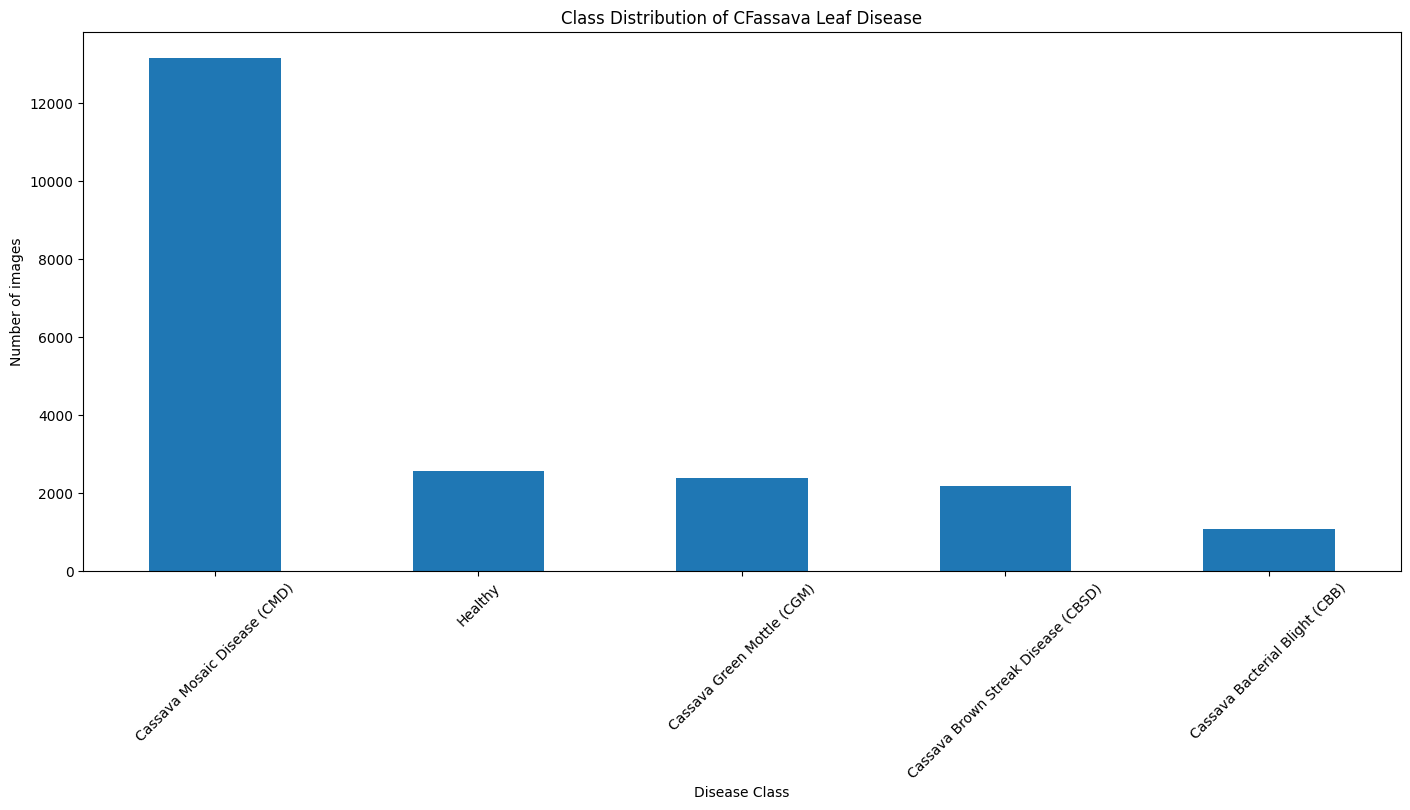

In [10]:
# step 4: check class distribution
class_distribution=df_train['class_name'].value_counts()
##plot the class distribution
plt.figure(figsize=(17,7))
class_distribution.plot(kind='bar')
plt.title('Class Distribution of CFassava Leaf Disease')
plt.ylabel("Number of images") 
plt.xlabel("Disease Class")
plt.xticks(rotation=45)
plt.show()


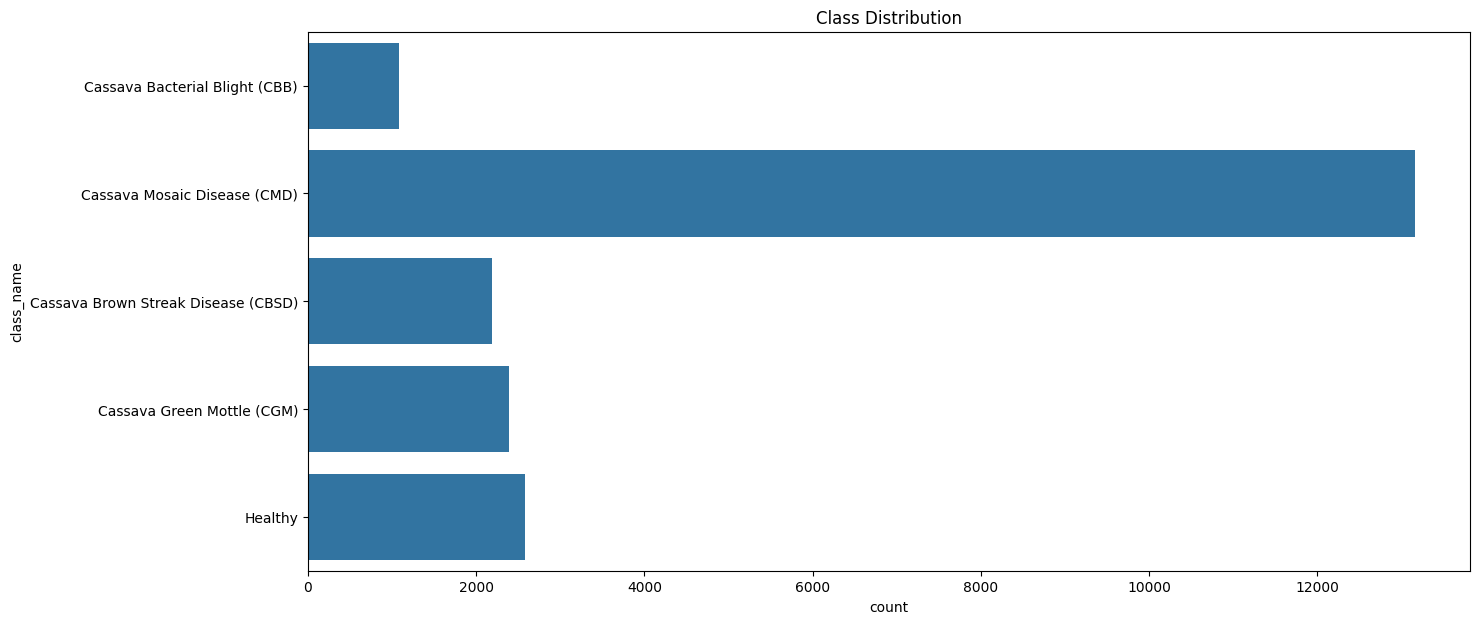

In [11]:
# alternatively use seaborn for a countplot visualization
plt.figure(figsize=(15,7))
sns.countplot(y='class_name',data=df_train)
plt.title("Class Distribution")
plt.show()

In [12]:
# step 5: basic dataset exploration
# show data info and summary statistics
print("dataset info: ")
print(df_train.info())

dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_id    21397 non-null  object
 1   label       21397 non-null  int64 
 2   class_name  21397 non-null  object
dtypes: int64(1), object(2)
memory usage: 501.6+ KB
None


In [13]:
print("\nDataset summary statistics: ")
print(df_train.describe())


Dataset summary statistics: 
              label
count  21397.000000
mean       2.651914
std        0.988565
min        0.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        4.000000


In [14]:
# step 6: check for missing values and duplicates
print(f"\nMissing values in each column: \n{df_train.isnull().sum()}")
print(f"\nNumber of duplicate rows: \n{df_train.duplicated().sum()}")


Missing values in each column: 
image_id      0
label         0
class_name    0
dtype: int64

Number of duplicate rows: 
0


In [15]:
path='/kaggle/input/competitions/cassava-leaf-disease-classification/train_images/1000015157.jpg'
path2='1000015157.jpg'

cv2.imread(path2)

[ WARN:0@464.121] global loadsave.cpp:278 findDecoder imread_('1000015157.jpg'): can't open/read file: check file path/integrity
